In [1]:
# config.py
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- Training Hyperparameters ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE_GEN = 1e-4
LEARNING_RATE_DISC = 1e-4
BATCH_SIZE = 16
NUM_EPOCHS_PRETRAIN = 50
NUM_EPOCHS_GAN = 100
HIGH_RES_SIZE = 96  # As per the paper
LOW_RES_SIZE = HIGH_RES_SIZE // 4
NUM_WORKERS = 4
LAMBDA_VGG = 1.0  # Weight for VGG/content loss
LAMBDA_ADV = 1e-3  # Weight for adversarial loss

os.makedirs("saved_models", exist_ok=True)

# --- Model Paths ---
PRETRAINED_GEN_PATH = "saved_models/srresnet_pretrained.pth"
GEN_PATH = "saved_models/generator.pth"
DISC_PATH = "saved_models/discriminator.pth"

# --- Dataset Paths ---
TRAIN_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_train_HR"
TEST_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_valid_HR"

# set the repo name
model_name = "keanteng/srgan-div2k-0723-v2"

In [10]:
import torch
from torch import nn

class ResidualBlock(nn.Module):
# Defines a custom neural network class that inherits from nn.Module
# This is the standard way to create custom layers/blocks in PyTorch
    """
    A single residual block as defined in the SRGAN paper.
    It contains two convolutional layers with batch normalization and PReLU activation.
    """
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        # Constructor method that takes in_channels as parameter (number of input feature maps)
        # super() calls the parent class constructor to properly initialize the module
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.PReLU(),
        # Creates first convolutional block as a sequential container
        # Conv2d: 2D convolution with 3x3 kernel, stride=1, padding=1 (preserves spatial dimensions)
        # kernel size is the dimension of the filter that slide over input data, normally a small square size
        # stride is the step size where filter moves one pixel at a time
        # BatchNorm2d: Batch normalization for stable training
        # PReLU: Parametric ReLU activation function (learnable parameter)
                
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
        )
        # Creates second convolutional block (similar to first but without activation)
        # No activation function here because it will be added to the residual connection

    def forward(self, x):
        identity = x
        out = self.conv_block1(x)
        out = self.conv_block2(out)
        return identity + out
        # Forward pass method defining how data flows through the block
        # identity = x: Stores original input for residual connection
        # Passes input through both conv blocks sequentially
        # Returns sum of processed output and original input (residual connection)

In [11]:
from torch import nn
import torch

class UpsampleBlock(nn.Module):
    """
    Upsampling block using a convolutional layer and PixelShuffle.
    This increases the resolution by a factor of 2.
    """
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), kernel_size=3, stride=1, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.prelu = nn.PReLU()

    def forward(self, x):
        return self.prelu(self.pixel_shuffle(self.conv(x)))

# Study 
## From The Paper
```
Our generator network has 16 identical (B = 16) residual blocks.
We scaled the range of the LR input images to [0,1] and for the HR images to [1,1]
```
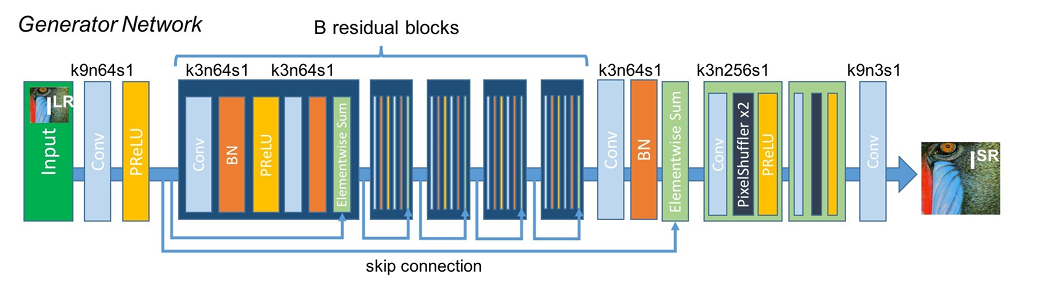

## Explanation

```python
self.initial_conv = nn.Sequential(
    nn.Conv2d(in_channels, 64, kernel_size=9, stride=1, padding=4),
    nn.PReLU()
)
```
- Why do we use padding = 4
    - Output size = (Input size - Kernel size + 2 * Padding) / Stride + 1
    - Output size = (96 - 9 + 2 * 4) / 1 + 1 = 96
    - So that the after going through the initial conv layer, the output size is still 96x96
    - Then we go through parameterized ReLU activation function

```python
self.residuals = nn.Sequential(*[ResidualBlock(64) for _ in range(num_res_blocks)])
```
- Then we passed through the residual blocks 16 times. What is the size after going through the residual blocks?
    - The size is still 96x96, because the residual block does not change the size of the input
    - Output size = (Input size - Kernel size + 2 * Padding) / Stride + 1
    - Output size = (96 - 3 + 2 * 1) / 1 + 1 = 96

```python
self.mid_conv = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64)
)
```
- For this layer, we also use padding = 1
    - Output size = (Input size - Kernel size + 2 * Padding) / Stride + 1
    - Output size = (96 - 3 + 2 * 1) / 1 + 1 = 96
    - So that the output size is still 96x96
    - We also use batch normalization to normalize the output of the residual blocks

```python
# Upsampling by 4x (two 2x upsample blocks)
self.upsample_blocks = nn.Sequential(
    UpsampleBlock(64),
    UpsampleBlock(64),
)
```
- We use two upsample blocks to increase the size by 4x
    - The first upsample block increases the size by 2x, and the second upsample block increases the size by another 2x
    - So the output size after going through the upsample blocks is 96 * 4 = 384

```python
self.final_conv = nn.Conv2d(64, in_channels, kernel_size=9, stride=1, padding=4)
```
- Finally, we use a convolution layer to reduce the number of channels back to the original number of channels
    - Output size = (Input size - Kernel size + 2 * Padding) / Stride + 1
    - Output size = (384 - 9 + 2 * 4) / 1 + 1 = 384
    - So the output size is still 384x384

### Why skip connection?
- The skip connection combines initial input with the output of the residual blocks

```
Imagine playing "telephone" or "whisper down the lane" with many people. If the message is passed through too many people, it can get distorted or completely disappear by the end.
Deep neural networks (networks with many layers) can have a similar problem with "information" (specifically, "gradients" which help the network learn). The learning signal can get weaker and weaker as it goes back through many layers, making the early layers hard to train.
Skip connections act like a direct loud speaker. They ensure the original message (or a strong learning signal) directly reaches earlier parts of the network, preventing it from getting lost or too weak.
```

```
Skip connections make it easy for the network to just "pass through" information unchanged if that's what's needed. Without them, even that simple "do nothing" task can be surprisingly difficult for the network to learn efficiently using its standard processing tools. The skip connection basically says, "Don't bother learning to perfectly copy; I'll just give you a direct copy!"
```

In [16]:
from torch import nn

class Generator(nn.Module):
    """
    The Generator Network (SRResNet).
    It takes a low-resolution image and outputs a super-resolved version.
    """
    def __init__(self, in_channels=3, num_res_blocks=16):
        super(Generator, self).__init__()
        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU()
        )

        self.residuals = nn.Sequential(*[ResidualBlock(64) for _ in range(num_res_blocks)])

        self.mid_conv = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64)
        )

        # Upsampling by 4x (two 2x upsample blocks)
        self.upsample_blocks = nn.Sequential(
            UpsampleBlock(64),
            UpsampleBlock(64),
        )

        self.final_conv = nn.Conv2d(64, in_channels, kernel_size=9, stride=1, padding=4)

    def forward(self, x):
        initial_out = self.initial_conv(x)
        residual_out = self.residuals(initial_out)
        mid_out = self.mid_conv(residual_out)
        mid_out = mid_out + initial_out # Skip connection
        upsampled_out = self.upsample_blocks(mid_out)
        final_out = self.final_conv(upsampled_out)
        return torch.tanh(final_out) # Tanh activation to scale output to [-1, 1], can be scaled back for display also

Output should be magnify by 4

In [14]:
in_channels = 2  # Number of input channels
batch_size = 1  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = Generator(in_channels)

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 2, 3, 3])
Input: tensor([[[[ 0.5011, -2.9006, -0.7493],
          [ 1.0656, -0.9038, -0.3169],
          [ 0.5116, -0.4260,  0.8635]],

         [[-1.7435,  1.7615,  0.8683],
          [ 2.1788, -1.6379, -0.7804],
          [ 0.5141, -0.0265, -1.1923]]]])
Output shape: torch.Size([1, 2, 12, 12])
Output: tensor([[[[ 2.1574e-02,  2.4088e-02,  4.2169e-02, -2.5332e-03, -6.4550e-03,
            5.3438e-02,  5.6853e-02,  9.5323e-03,  2.5671e-02,  5.6999e-02,
            6.5032e-03,  6.8008e-02],
          [ 2.1964e-03, -3.2052e-02, -3.4156e-02,  3.8087e-02,  5.1648e-02,
            1.1468e-01,  9.1333e-02,  2.0021e-01,  4.7781e-02, -1.4569e-02,
            4.2643e-02,  3.7791e-02],
          [ 5.8043e-02, -3.8897e-02,  3.2680e-02,  1.4620e-01, -4.7290e-02,
            6.0462e-04,  8.1156e-02,  1.2562e-01,  9.2589e-02,  2.7612e-02,
            5.8196e-02,  3.0692e-02],
          [ 1.0725e-04, -8.1486e-02, -7.0350e-02, -1.1840e-01,  2.4069e-02,
            6.2583e-0

In [15]:
print(torch.tanh(output))

tensor([[[[ 2.1571e-02,  2.4083e-02,  4.2144e-02, -2.5331e-03, -6.4550e-03,
            5.3387e-02,  5.6792e-02,  9.5320e-03,  2.5665e-02,  5.6937e-02,
            6.5031e-03,  6.7904e-02],
          [ 2.1964e-03, -3.2041e-02, -3.4143e-02,  3.8069e-02,  5.1602e-02,
            1.1418e-01,  9.1080e-02,  1.9758e-01,  4.7745e-02, -1.4568e-02,
            4.2617e-02,  3.7773e-02],
          [ 5.7978e-02, -3.8877e-02,  3.2669e-02,  1.4517e-01, -4.7255e-02,
            6.0462e-04,  8.0978e-02,  1.2496e-01,  9.2325e-02,  2.7605e-02,
            5.8131e-02,  3.0682e-02],
          [ 1.0725e-04, -8.1306e-02, -7.0234e-02, -1.1785e-01,  2.4065e-02,
            6.2501e-02,  2.7929e-02, -5.1345e-02,  7.1292e-02, -3.7467e-02,
           -5.5312e-02,  6.1497e-02],
          [ 9.8145e-02,  1.1924e-01,  1.0144e-01,  1.0186e-01,  1.7415e-01,
            7.4778e-02,  1.2798e-01,  1.0774e-01,  4.9136e-02,  7.9544e-02,
            3.9819e-02,  1.4574e-02],
          [ 2.6442e-03, -2.1018e-02, -3.4660e-02, 